### 📊 AED para Insights Criativos

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**Análises adicionais com valor estratégico para a ONG:**
1. Mapa de risco multidimensional — perfil dos alunos mais vulneráveis
2. O efeito "nível 3" — por que esse nível é tão diferente?
3. Análise de evasão/retenção — quem saiu do programa e por quê?
4. Efeito da instituição de ensino ao longo do tempo — escola pública fecha a lacuna?

### ⚙️ Import e Setup

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../../data/db/01_silver_processed/df_base_2.parquet')

indicadores = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')
df['nivel'].unique()

df_base: 3030 linhas | 31 colunas


array(['7', '6', '5', '4', '3', '2', '1', 'ALFA', '8', '9'], dtype=object)

### 1. Mapa de risco multidimensional

Nos pilares anteriores, identificamos vários fatores de risco isolados. Aqui vamos cruzá-los para criar um perfil composto de vulnerabilidade.

=== Distribuição do score de risco por ano ===

  2022 (n=860):
    Score 0:   60 (7.0%)
    Score 1:  224 (26.0%)
    Score 2:  254 (29.5%)
    Score 3:  174 (20.2%)
    Score 4:  123 (14.3%)
    Score 5:   25 (2.9%)

  2023 (n=1014):
    Score 0:  186 (18.3%)
    Score 1:  314 (31.0%)
    Score 2:  259 (25.5%)
    Score 3:  152 (15.0%)
    Score 4:   92 (9.1%)
    Score 5:   11 (1.1%)

  2024 (n=1156):
    Score 0:  273 (23.6%)
    Score 1:  275 (23.8%)
    Score 2:  286 (24.7%)
    Score 3:  196 (17.0%)
    Score 4:  104 (9.0%)
    Score 5:   22 (1.9%)

=== INDE médio por score de risco e ano ===
ano          2022  2023  2024
score_risco                  
0            8.16  7.94  8.44
1            7.68  7.77  7.92
2            7.27  7.31  7.38
3            6.60  6.69  6.67
4            5.80  6.42  6.05
5            5.25  6.28  5.83

=== % de alunos com risco alto (score >= 4) por ano ===
  2022: 148 alunos (17.2%)
  2023: 103 alunos (10.2%)
  2024: 126 alunos (10.9%)


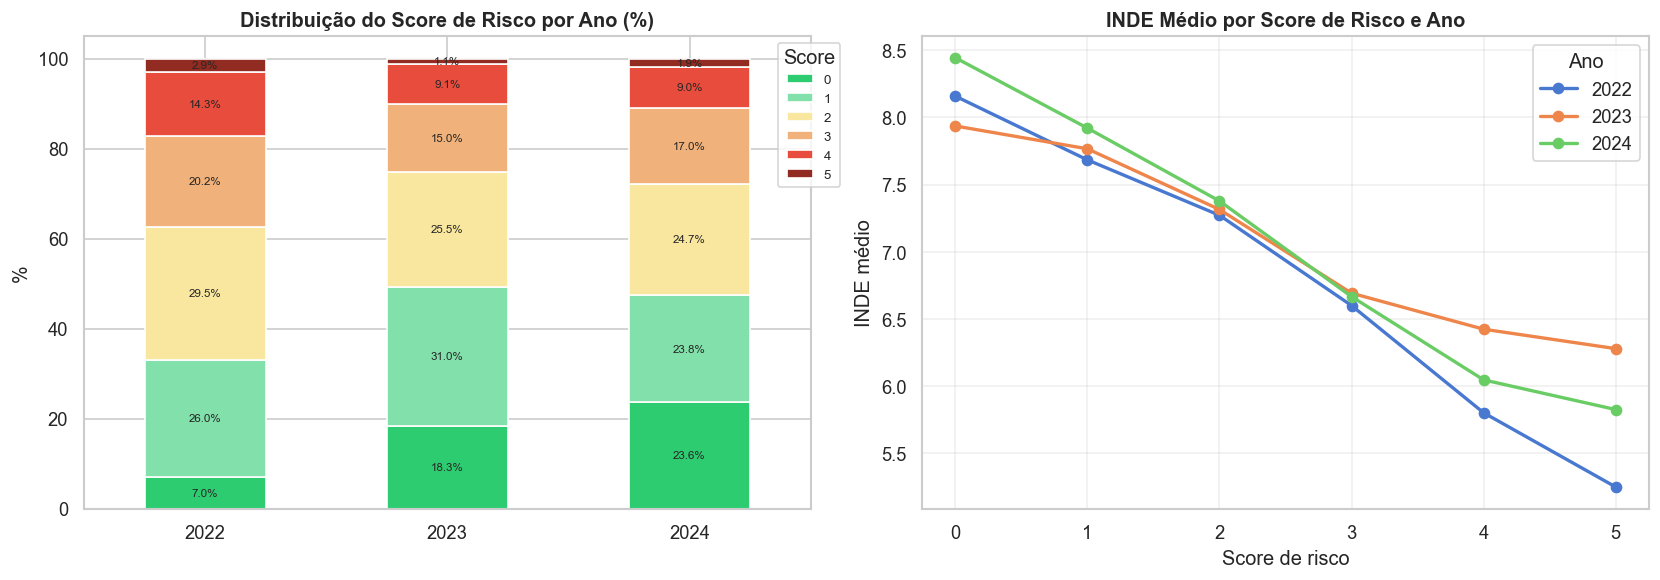

In [9]:
# Construir score de risco baseado nos achados dos pilares anteriores
df_risco = df.copy()

# Fatores de risco identificados nos pilares

# (Pergunta 1) alunos com IAN abaixo de 10 são considerados em risco de defasagem 
df_risco['risco_defasagem'] = (df_risco['IAN'] < 10).astype(int)                                

# (Pergunta 1)
df_risco['risco_primeiro_ano'] = (df_risco['ano_ingresso'] == df_risco['ano']).astype(int)

# (Pergunta 2) alunos com IDA abaixo do 25º percentil são considerados em risco de baixo desempenho
df_risco['risco_ida_baixo'] = df_risco.groupby('ano')['IDA'].transform(
    lambda x: (x < x.quantile(0.25)).astype(int)
)

# (Pergunta 3) Baixo engajamento tem maior chance de queda futura
df_risco['risco_ieg_baixo'] = df_risco.groupby('ano')['IEG'].transform(
    lambda x: (x < x.quantile(0.25)).astype(int)
)

# (Pergunta 4) Alunos que se dão nota 2+ pontos acima do desempenho real.
# Esses alunos não percebem que estão em dificuldade - especialmente concentrados no nível 3
df_risco['risco_superestima'] = ((df_risco['IAA'] - df_risco['IDA']) > 2).astype(int)


# Score composto
fatores = ['risco_defasagem', 'risco_ida_baixo', 'risco_superestima',
           'risco_ieg_baixo', 'risco_primeiro_ano']
df_risco['score_risco'] = df_risco[fatores].sum(axis=1)

# Distribuição por ano
print('=== Distribuição do score de risco por ano ===')
for ano in [2022, 2023, 2024]:
    sub = df_risco[df_risco['ano'] == ano]
    print(f'\n  {ano} (n={len(sub)}):')
    dist = sub['score_risco'].value_counts().sort_index()
    for score, n in dist.items():
        print(f'    Score {score}: {n:4d} ({n/len(sub)*100:.1f}%)')

# INDE médio por score e ano
print('\n=== INDE médio por score de risco e ano ===')
pivot_inde = df_risco.pivot_table(index='score_risco', columns='ano', values='INDE', aggfunc='mean').round(2)
print(pivot_inde.to_string())

# % de risco alto (score >= 4) por ano
print('\n=== % de alunos com risco alto (score >= 4) por ano ===')
for ano in [2022, 2023, 2024]:
    sub = df_risco[df_risco['ano'] == ano]
    pct = (sub['score_risco'] >= 4).mean() * 100
    n = (sub['score_risco'] >= 4).sum()
    print(f'  {ano}: {n} alunos ({pct:.1f}%)')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do score por ano (empilhado %)
ct = pd.crosstab(df_risco['ano'], df_risco['score_risco'], normalize='index') * 100
cores_risco = {0: '#2ecc71', 1: '#82e0aa', 2: '#f9e79f', 3: '#f0b27a', 4: '#e74c3c', 5: '#922b21'}
ct.plot(kind='bar', stacked=True, ax=axes[0],
        color=[cores_risco.get(i, '#999') for i in ct.columns])
axes[0].set_title('Distribuição do Score de Risco por Ano (%)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Score', bbox_to_anchor=(1.05, 1), fontsize=8)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=7)

# INDE por score (linhas por ano)
for ano in [2022, 2023, 2024]:
    sub = df_risco[df_risco['ano'] == ano]
    inde_score = sub.groupby('score_risco')['INDE'].mean()
    axes[1].plot(inde_score.index, inde_score.values, marker='o', linewidth=2, label=str(ano))

axes[1].set_title('INDE Médio por Score de Risco e Ano', fontweight='bold')
axes[1].set_xlabel('Score de risco')
axes[1].set_ylabel('INDE médio')
axes[1].legend(title='Ano')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 💡 Insights

**O score de risco composto é consistente nos 3 anos:**
- Gradiente claro: score 0 -> INDE ~8.2, score 5 -> INDE ~5.8
- Cada ponto adicional de risco reduz o INDE em ~0.5 pontos — padrão estável entre anos

**O programa está reduzindo o risco ao longo do tempo:**
- Alunos sem risco (score 0) triplicaram: 7.0% (2022) -> 23.6% (2024)
- Alunos com risco alto (score ≥ 4) caíram: 17.2% (2022) -> 10.9% (2024)
- A base está se deslocando para a esquerda (menor risco) ao longo dos anos

**10.9% dos alunos em 2024 (126) permanecem em risco alto (score ≥ 4):**
- São o grupo prioritário para intervenção
- Perfil: defasados, IDA no quartil inferior, desengajados, se superestimam e/ou no primeiro ano

**O IAA não acompanha o risco:** mesmo com score 5, o IAA permanece acima de 8.0 — os alunos mais vulneráveis não percebem sua situação

**💡 Para a ONG:** o score composto pode ser uma ferramenta prática de triagem — identificar os 10-15% de risco alto a cada ano para direcionar acompanhamento individualizado

### 2. O efeito "nível 3"

O nível 3 apareceu como ponto crítico em 3 perguntas: pior IDA (Pergunta 2), maior superestimação IAA-IDA (Pergunta 4), e onde o programa tem mais impacto (Pergunta 10). O que o torna tão diferente?

=== Perfil comparativo: Nível 3 vs Outros ===
  IAN  : N3=7.87, Outros=7.05, diff=+0.83
  IDA  : N3=5.39, Outros=6.58, diff=-1.19
  IEG  : N3=7.58, Outros=8.37, diff=-0.79
  IAA  : N3=7.62, Outros=7.98, diff=-0.36
  IPS  : N3=6.36, Outros=6.27, diff=+0.09
  IPP  : N3=7.38, Outros=7.14, diff=+0.24
  IPV  : N3=7.00, Outros=7.66, diff=-0.66
  INDE : N3=6.92, Outros=7.34, diff=-0.43

=== Gap IAA-IDA por nível ===
       gap_medio  gap_mediano    n
nivel                             
1           1.56         1.75  550
2           1.50         1.90  539
3           2.22         2.70  491
4           1.65         2.00  285
5           1.57         1.83  225
6           0.24         1.46   76
7           2.05         1.83   68
ALFA        1.11         1.30  617

=== % de alunos defasados por nível ===
nivel
1       77.3
2       56.3
3       40.7
4       55.8
5       62.7
6       67.1
7       27.2
8        0.0
9        0.0
ALFA    62.4

=== IDA médio do nível 3 por ano ===
      mean  count
ano 

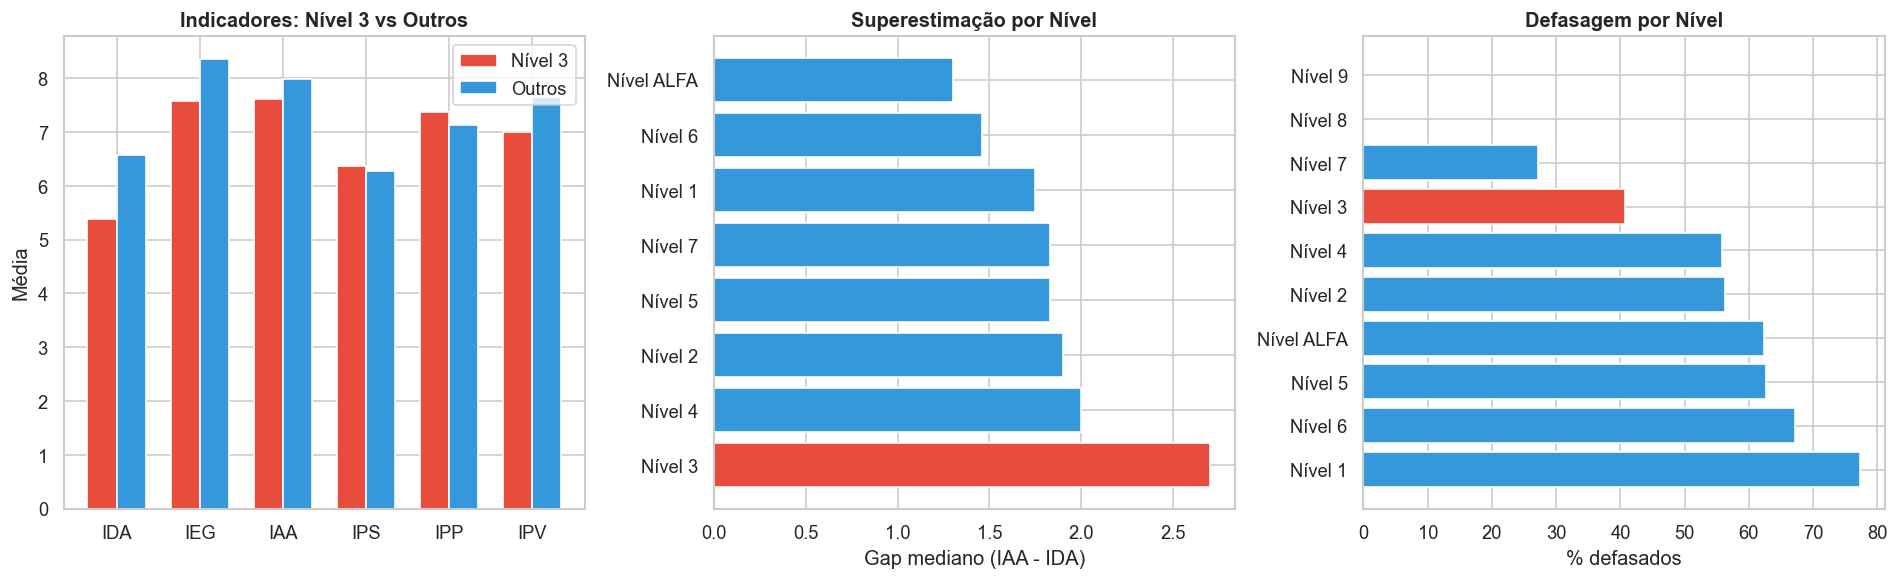

In [10]:
# Comparar nível 3 com os demais em múltiplas dimensões
df_n3 = df.copy()
df_n3['grupo'] = np.where(df_n3['nivel'] == '3', 'Nível 3', 'Outros níveis')

# Perfil comparativo
print('=== Perfil comparativo: Nível 3 vs Outros ===')
comparativo = df_n3.groupby('grupo')[indicadores + ['INDE']].agg(['mean', 'median', 'count']).round(2)
for ind in indicadores + ['INDE']:
    n3_mean = df_n3[df_n3['grupo'] == 'Nível 3'][ind].mean()
    outros_mean = df_n3[df_n3['grupo'] == 'Outros níveis'][ind].mean()
    diff = n3_mean - outros_mean
    print(f'  {ind:5}: N3={n3_mean:.2f}, Outros={outros_mean:.2f}, diff={diff:+.2f}')

# Gap IAA-IDA por nível (reforçando o achado do Pilar 4)
df_gap = df[df['IDA'].notna() & df['IAA'].notna()].copy()
df_gap['gap'] = df_gap['IAA'] - df_gap['IDA']

gap_nivel = df_gap.groupby('nivel')['gap'].agg(['mean', 'median', 'count']).round(2)
gap_nivel.columns = ['gap_medio', 'gap_mediano', 'n']

print('\n=== Gap IAA-IDA por nível ===')
print(gap_nivel.to_string())

# % de defasagem por nível
df_def = df[df['IAN'].notna()].copy()
def_nivel = df_def.groupby('nivel')['IAN'].apply(lambda x: (x < 10).mean() * 100).round(1)
print('\n=== % de alunos defasados por nível ===')
print(def_nivel.to_string())

# Evolução do nível 3 ao longo dos anos
print('\n=== IDA médio do nível 3 por ano ===')
n3_ida = df[df['nivel'] == '3'].groupby('ano')['IDA'].agg(['mean', 'count']).round(2)
print(n3_ida.to_string())

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Radar simplificado: barras comparativas
inds_plot = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
n3_vals = [df_n3[df_n3['grupo'] == 'Nível 3'][ind].mean() for ind in inds_plot]
outros_vals = [df_n3[df_n3['grupo'] == 'Outros níveis'][ind].mean() for ind in inds_plot]

x = np.arange(len(inds_plot))
width = 0.35
axes[0].bar(x - width/2, n3_vals, width, label='Nível 3', color='#e74c3c')
axes[0].bar(x + width/2, outros_vals, width, label='Outros', color='#3498db')
axes[0].set_xticks(x)
axes[0].set_xticklabels(inds_plot)
axes[0].set_ylabel('Média')
axes[0].set_title('Indicadores: Nível 3 vs Outros', fontweight='bold')
axes[0].legend()

# Gap por nível
gap_nivel_sorted = gap_nivel.sort_values('gap_mediano', ascending=False)
cores_gap = ['#e74c3c' if idx == '3' else '#3498db' for idx in gap_nivel_sorted.index]
axes[1].barh(range(len(gap_nivel_sorted)), gap_nivel_sorted['gap_mediano'], color=cores_gap)
axes[1].set_yticks(range(len(gap_nivel_sorted)))
axes[1].set_yticklabels([f'Nível {n}' for n in gap_nivel_sorted.index])
axes[1].set_xlabel('Gap mediano (IAA - IDA)')
axes[1].set_title('Superestimação por Nível', fontweight='bold')

# % defasagem por nível
def_sorted = def_nivel.sort_values(ascending=False)
cores_def = ['#e74c3c' if idx == '3' else '#3498db' for idx in def_sorted.index]
axes[2].barh(range(len(def_sorted)), def_sorted.values, color=cores_def)
axes[2].set_yticks(range(len(def_sorted)))
axes[2].set_yticklabels([f'Nível {n}' for n in def_sorted.index])
axes[2].set_xlabel('% defasados')
axes[2].set_title('Defasagem por Nível', fontweight='bold')

plt.tight_layout()
plt.show()

##### 💡 Insights — O efeito nível 3

**O nível 3 é um gargalo acadêmico, não de defasagem:**
- Pior IDA da base: 5.39 vs 6.58 dos outros (-1.19 pontos) — consistente nos 3 anos (5.14 -> 5.75 -> 5.35)
- IEG também abaixo (-0.79) e IPV abaixo (-0.66)
- Porém IPS e IPP são normais — o problema é acadêmico e de engajamento, não psicossocial

**A superestimação agrava o problema:**
- Gap mediano IAA-IDA de 2.70 — o maior de todos os níveis, com folga
- O aluno típico do nível 3 se dá quase 3 pontos acima do desempenho real
- Combinação perigosa: desempenho baixo + autopercepção inflada = aluno que não percebe que precisa de ajuda

**Paradoxo: o nível 3 não é o mais defasado (40.7%) mas é o que aprende menos**
- Níveis 1 (77.3%) e ALFA (62.4%) têm mais defasagem, porém o IDA do nível 3 é pior
- O problema não é estar na fase errada — é estar na fase certa mas não absorver o conteúdo

**Contexto etário:**
- O nível 3 equivale ao 7º/8º ano (~12-14 anos).
- A pré-adolescência traz aumento de complexidade acadêmica e mudanças comportamentais típicas da faixa etária, o que pode explicar tanto a queda de IDA quanto a superestimação — padrão comum nessa idade

**💡 Para a ONG:**
- o nível 3 precisa de intervenção dupla: reforço acadêmico + feedback realista sobre desempenho para calibrar a autopercepção. 
- É também o nível onde o programa tem mais impacto (Pergunta 10: INDE +0.34), o que sugere que investir aqui tem alto retorno

### 3. Análise de evasão/retenção

Quem saiu do programa? Qual era o perfil desses alunos antes de sair?

=== Retenção e evasão ===
  Alunos em 2022: 860
  Saíram entre 2022 e 2023: 260 (30.2%)
  Saíram entre 2023 e 2024: 249 (24.6%)
  Presentes nos 3 anos: 468

=== Perfil: Saíram após 2022 (n=260) ===
  IAN  : média=6.19
  IDA  : média=5.23
  IEG  : média=6.95
  IAA  : média=7.89
  IPS  : média=6.91
  IPP  : média=6.26
  IPV  : média=6.79
  INDE : média=6.51
  Pedras: Ágata=32.7%, Ametista=32.3%, Quartzo=30.4%, Topázio=4.6%

=== Perfil: Ficaram após 2022 (n=600) ===
  IAN  : média=6.53
  IDA  : média=6.47
  IEG  : média=8.30
  IAA  : média=8.44
  IPS  : média=6.90
  IPP  : média=6.35
  IPV  : média=7.45
  INDE : média=7.26
  Pedras: Ametista=44.0%, Ágata=27.5%, Topázio=19.7%, Quartzo=8.8%

=== Perfil: Saíram após 2023 (n=249) ===
  IAN  : média=6.75
  IDA  : média=6.20
  IEG  : média=8.23
  IAA  : média=6.64
  IPS  : média=5.01
  IPP  : média=7.41
  IPV  : média=7.78
  INDE : média=7.02
  Pedras: Ágata=38.6%, Ametista=30.3%, Topázio=18.7%, Quartzo=12.4%

=== Perfil: Ficaram após 2023 (n=7

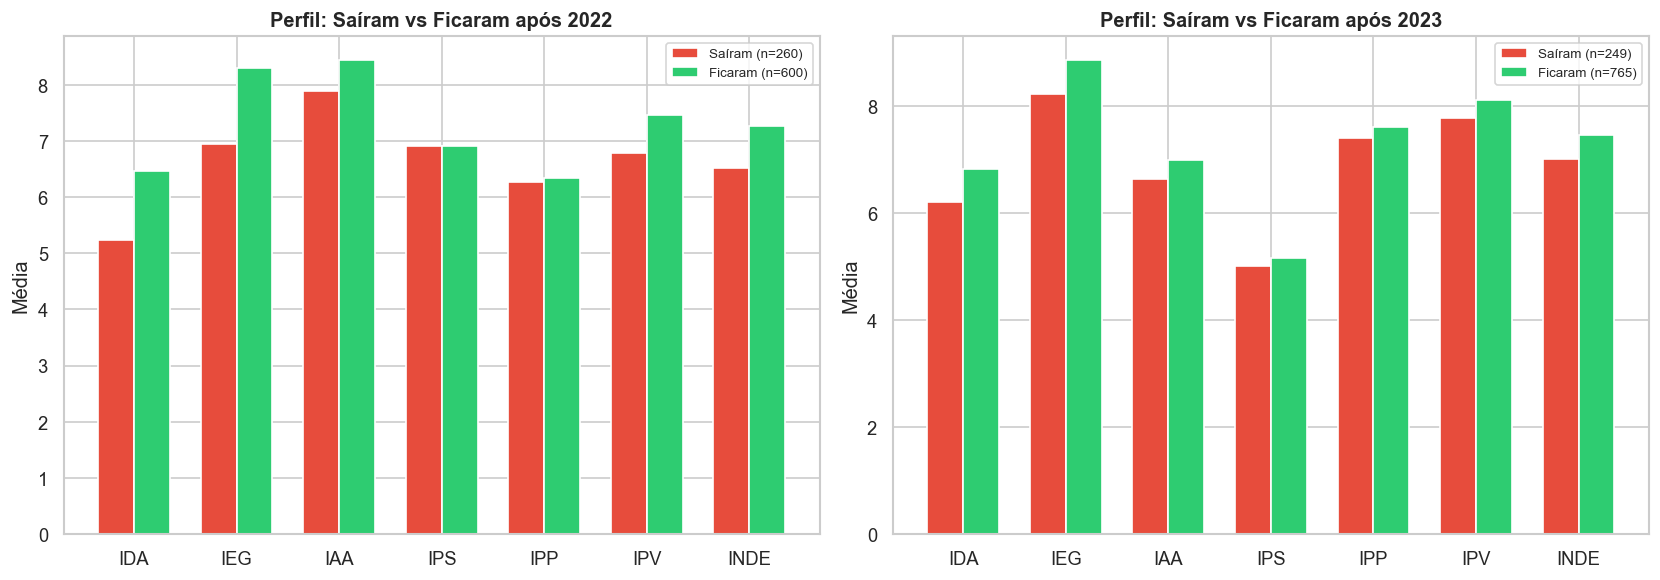

In [11]:
# Identificar alunos que saíram do programa
# Critério: presente em um ano mas não no seguinte (e não é o último ano)
ras_por_ano = df.groupby('ano')['RA'].apply(set)

# Saíram entre 2022 e 2023
saiu_22_23 = ras_por_ano[2022] - ras_por_ano[2023]
# Saíram entre 2023 e 2024
saiu_23_24 = ras_por_ano[2023] - ras_por_ano[2024]
# Ficaram todos os anos
ficou_todos = ras_por_ano[2022] & ras_por_ano[2023] & ras_por_ano[2024]

print(f'=== Retenção e evasão ===')
print(f'  Alunos em 2022: {len(ras_por_ano[2022])}')
print(f'  Saíram entre 2022 e 2023: {len(saiu_22_23)} ({len(saiu_22_23)/len(ras_por_ano[2022])*100:.1f}%)')
print(f'  Saíram entre 2023 e 2024: {len(saiu_23_24)} ({len(saiu_23_24)/len(ras_por_ano[2023])*100:.1f}%)')
print(f'  Presentes nos 3 anos: {len(ficou_todos)}')

# Perfil de quem saiu vs quem ficou (usando último ano disponível)
def perfil_grupo(ras, ano, label):
    sub = df[(df['RA'].isin(ras)) & (df['ano'] == ano)]
    print(f'\n=== Perfil: {label} (n={len(sub)}) ===')
    for ind in indicadores + ['INDE']:
        print(f'  {ind:5}: média={sub[ind].mean():.2f}')
    if 'pedra' in sub.columns:
        pedras = sub['pedra'].value_counts(normalize=True) * 100
        print(f'  Pedras: {", ".join([f"{p}={v:.1f}%" for p, v in pedras.items()])}')

perfil_grupo(saiu_22_23, 2022, 'Saíram após 2022')
perfil_grupo(ras_por_ano[2022] - saiu_22_23, 2022, 'Ficaram após 2022')

perfil_grupo(saiu_23_24, 2023, 'Saíram após 2023')
perfil_grupo(ras_por_ano[2023] - saiu_23_24, 2023, 'Ficaram após 2023')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparação saiu vs ficou — 2022
for i, (ano, saiu) in enumerate([(2022, saiu_22_23), (2023, saiu_23_24)]):
    ficou = ras_por_ano[ano] - saiu
    
    saiu_df = df[(df['RA'].isin(saiu)) & (df['ano'] == ano)]
    ficou_df = df[(df['RA'].isin(ficou)) & (df['ano'] == ano)]
    
    inds_plot = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
    saiu_vals = [saiu_df[ind].mean() for ind in inds_plot]
    ficou_vals = [ficou_df[ind].mean() for ind in inds_plot]
    
    x = np.arange(len(inds_plot))
    width = 0.35
    axes[i].bar(x - width/2, saiu_vals, width, label=f'Saíram (n={len(saiu)})', color='#e74c3c')
    axes[i].bar(x + width/2, ficou_vals, width, label=f'Ficaram (n={len(ficou)})', color='#2ecc71')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(inds_plot)
    axes[i].set_ylabel('Média')
    axes[i].set_title(f'Perfil: Saíram vs Ficaram após {ano}', fontweight='bold')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# Nível dos alunos que saíram — separar conclusão de possível evasão
for transicao, saiu, ano in [('2022->2023', saiu_22_23, 2022), ('2023->2024', saiu_23_24, 2023)]:
    sub = df[(df['RA'].isin(saiu)) & (df['ano'] == ano)]
    
    print(f'\n=== Nível dos que saíram após {ano} (n={len(sub)}) ===')
    nivel_dist = sub['nivel'].value_counts().sort_index()
    for nivel, n in nivel_dist.items():
        pct = n / len(sub) * 100
        print(f'  Nível {nivel:5}: {n:4d} ({pct:.1f}%)')
    
    # Separar: níveis altos (possível conclusão) vs baixos (possível evasão)
    possiveis_concluintes = sub[sub['nivel'].isin(['7', '8'])]['RA'].nunique()
    possiveis_evasao = sub[~sub['nivel'].isin(['7', '8'])]['RA'].nunique()
    print(f'\n  Possíveis concluintes (nível 7-8): {possiveis_concluintes} ({possiveis_concluintes/len(sub)*100:.1f}%)')
    print(f'  Possível evasão (níveis ALFA-6): {possiveis_evasao} ({possiveis_evasao/len(sub)*100:.1f}%)')
    
    # Perfil dos possíveis evadidos vs concluintes
    evadidos = sub[~sub['nivel'].isin(['7', '8'])]
    concluintes = sub[sub['nivel'].isin(['7', '8'])]
    
    print(f'\n  Perfil — Possíveis evadidos (n={len(evadidos)}):')
    print(f'    INDE médio: {evadidos["INDE"].mean():.2f}')
    print(f'    IDA médio: {evadidos["IDA"].mean():.2f}')
    
    if len(concluintes) > 0:
        print(f'\n  Perfil — Possíveis concluintes (n={len(concluintes)}):')
        print(f'    INDE médio: {concluintes["INDE"].mean():.2f}')
        print(f'    IDA médio: {concluintes["IDA"].mean():.2f}')


=== Nível dos que saíram após 2022 (n=260) ===
  Nível 1    :   50 (19.2%)
  Nível 2    :   43 (16.5%)
  Nível 3    :   63 (24.2%)
  Nível 4    :   26 (10.0%)
  Nível 5    :   20 (7.7%)
  Nível 6    :    6 (2.3%)
  Nível 7    :   10 (3.8%)
  Nível ALFA :   42 (16.2%)

  Possíveis concluintes (nível 7-8): 10 (3.8%)
  Possível evasão (níveis ALFA-6): 250 (96.2%)

  Perfil — Possíveis evadidos (n=250):
    INDE médio: 6.51
    IDA médio: 5.22

  Perfil — Possíveis concluintes (n=10):
    INDE médio: 6.52
    IDA médio: 5.36

=== Nível dos que saíram após 2023 (n=249) ===
  Nível 1    :   35 (14.1%)
  Nível 2    :   47 (18.9%)
  Nível 3    :   38 (15.3%)
  Nível 4    :   27 (10.8%)
  Nível 5    :   22 (8.8%)
  Nível 6    :   16 (6.4%)
  Nível 7    :    3 (1.2%)
  Nível 8    :    4 (1.6%)
  Nível ALFA :   57 (22.9%)

  Possíveis concluintes (nível 7-8): 7 (2.8%)
  Possível evasão (níveis ALFA-6): 242 (97.2%)

  Perfil — Possíveis evadidos (n=242):
    INDE médio: 7.01
    IDA médio: 6.18



##### 💡 Insights

**96-97% dos que saem NÃO são concluintes**
- **A evasão é real**, não conclusão natural do programa
- Após 2022: apenas 10 de 260 (3.8%) estavam no nível 7-8
- Após 2023: apenas 7 de 249 (2.8%) estavam no nível 7-8

**A evasão é concentrada nos níveis mais baixos:**
- ALFA + níveis 1-3 representam ~60-70% das saídas
- Nível 3 lidera em 2022 (24.2%) —> o mesmo gargalo acadêmico identificado nos pilares anteriores
- ALFA lidera em 2023 (22.9%) —> alunos na alfabetização que não continuam

**💡 Para a ONG:** a evasão é um problema real e concentrado na base do programa. O perfil de quem sai (IDA e IEG baixos, níveis iniciais) reforça que intervenção precoce nos primeiros níveis pode ter duplo efeito: melhorar desempenho e reduzir evasão

=== Base para análise de abandono ===
  Total: 1767
  Saíram: 492 (27.8%)
  Ficaram: 1275

=== Taxa de abandono por nível ===
       taxa_abandono    n
nivel                    
6               43.1   51
3               36.1  280
5               33.6  125
4               31.2  170
2               25.4  355
ALFA            23.5  421
1               23.3  365

=== Taxa de abandono por pedra ===
          taxa_abandono    n
pedra                       
Quartzo            53.3  197
Ágata              35.8  489
Ametista           21.3  718
Topázio            15.4  356

=== Taxa de abandono: primeiro ano vs veterano ===
              taxa_abandono     n
Veterano               24.6  1017
Primeiro ano           32.3   750

=== Correlação dos indicadores com abandono ===
  IAN   × abandono: r=-0.077 (n=1767)
  IDA   × abandono: r=-0.237 (n=1766)
  IEG   × abandono: r=-0.331 (n=1767)
  IAA   × abandono: r=-0.058 (n=1767)
  IPS   × abandono: r=0.008 (n=1761)
  IPP   × abandono: r=-0.063 (n=1767)


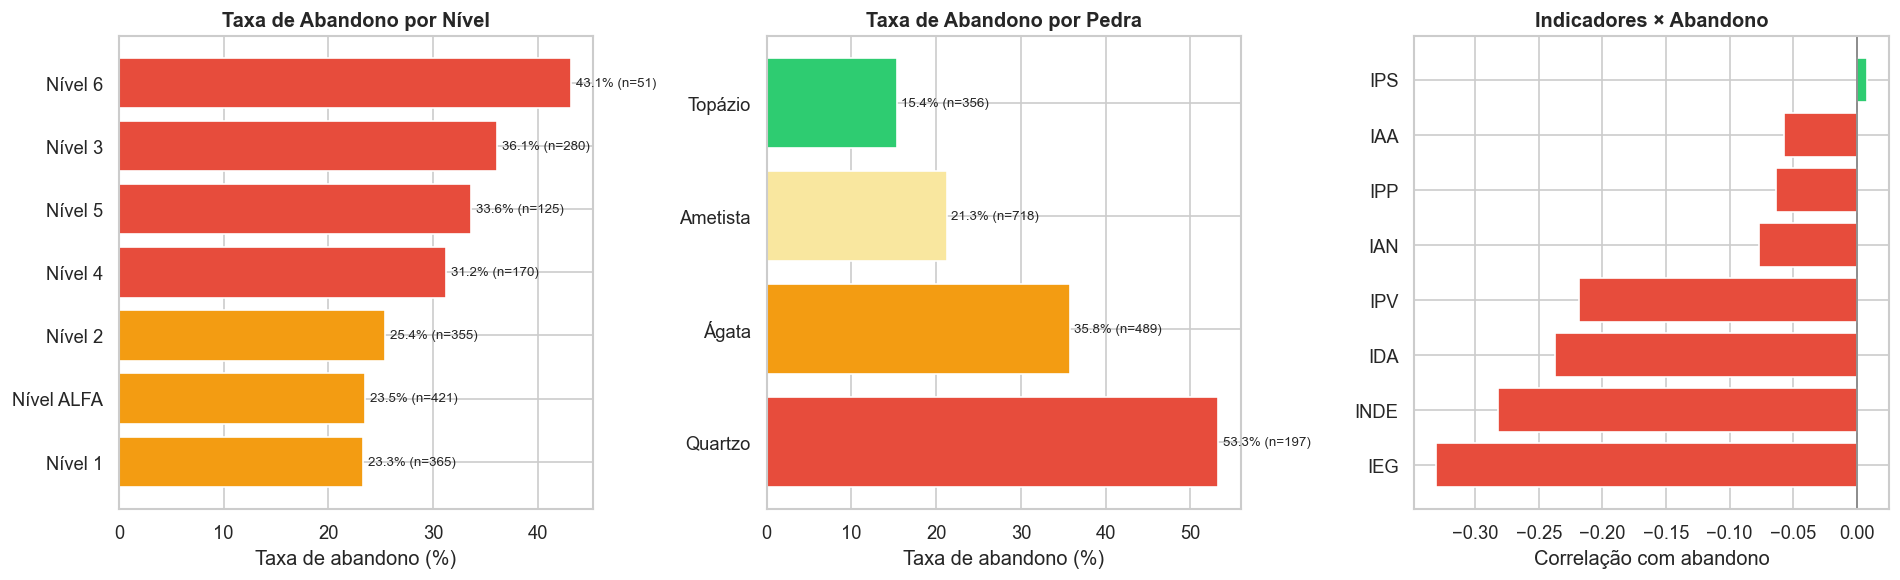

In [13]:
# Construir perfil de risco de abandono
# Criar flag: saiu no ano seguinte (1) ou ficou (0)
df_abandono = df[df['ano'].isin([2022, 2023])].copy()

# Para cada aluno-ano, verificar se aparece no ano seguinte
ras_2023 = set(df[df['ano'] == 2023]['RA'])
ras_2024 = set(df[df['ano'] == 2024]['RA'])

df_abandono['saiu'] = 0
df_abandono.loc[(df_abandono['ano'] == 2022) & (~df_abandono['RA'].isin(ras_2023)), 'saiu'] = 1
df_abandono.loc[(df_abandono['ano'] == 2023) & (~df_abandono['RA'].isin(ras_2024)), 'saiu'] = 1

# Excluir possíveis concluintes (nível 7-8)
df_abandono = df_abandono[~df_abandono['nivel'].isin(['7', '8'])].copy()

print(f'=== Base para análise de abandono ===')
print(f'  Total: {len(df_abandono)}')
print(f'  Saíram: {df_abandono["saiu"].sum()} ({df_abandono["saiu"].mean()*100:.1f}%)')
print(f'  Ficaram: {(df_abandono["saiu"] == 0).sum()}')

# Taxa de abandono por variável
print(f'\n=== Taxa de abandono por nível ===')
taxa_nivel = df_abandono.groupby('nivel')['saiu'].agg(['mean', 'count'])
taxa_nivel.columns = ['taxa_abandono', 'n']
taxa_nivel['taxa_abandono'] = (taxa_nivel['taxa_abandono'] * 100).round(1)
print(taxa_nivel.sort_values('taxa_abandono', ascending=False).to_string())

print(f'\n=== Taxa de abandono por pedra ===')
taxa_pedra = df_abandono.groupby('pedra')['saiu'].agg(['mean', 'count'])
taxa_pedra.columns = ['taxa_abandono', 'n']
taxa_pedra['taxa_abandono'] = (taxa_pedra['taxa_abandono'] * 100).round(1)
print(taxa_pedra.sort_values('taxa_abandono', ascending=False).to_string())

print(f'\n=== Taxa de abandono: primeiro ano vs veterano ===')
df_abandono['primeiro_ano'] = (df_abandono['ano_ingresso'] == df_abandono['ano']).astype(int)
taxa_status = df_abandono.groupby('primeiro_ano')['saiu'].agg(['mean', 'count'])
taxa_status.columns = ['taxa_abandono', 'n']
taxa_status['taxa_abandono'] = (taxa_status['taxa_abandono'] * 100).round(1)
taxa_status.index = ['Veterano', 'Primeiro ano']
print(taxa_status.to_string())

# Correlação dos indicadores com abandono
print(f'\n=== Correlação dos indicadores com abandono ===')
for ind in indicadores + ['INDE']:
    dados = df_abandono[['saiu', ind]].dropna()
    if len(dados) > 10:
        corr = dados['saiu'].corr(dados[ind])
        print(f'  {ind:5} × abandono: r={corr:.3f} (n={len(dados)})')

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Taxa por nível
taxa_nivel_sorted = taxa_nivel.sort_values('taxa_abandono', ascending=True)
axes[0].barh(range(len(taxa_nivel_sorted)), taxa_nivel_sorted['taxa_abandono'],
             color=['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#2ecc71' 
                    for v in taxa_nivel_sorted['taxa_abandono']])
axes[0].set_yticks(range(len(taxa_nivel_sorted)))
axes[0].set_yticklabels([f'Nível {n}' for n in taxa_nivel_sorted.index])
axes[0].set_xlabel('Taxa de abandono (%)')
axes[0].set_title('Taxa de Abandono por Nível', fontweight='bold')

for i, (nivel, row) in enumerate(taxa_nivel_sorted.iterrows()):
    axes[0].text(row['taxa_abandono'] + 0.5, i, f'{row["taxa_abandono"]:.1f}% (n={int(row["n"])})',
                 va='center', fontsize=8)

# Taxa por pedra
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
taxa_pedra_sorted = taxa_pedra.reindex(ordem_pedras).dropna()
axes[1].barh(range(len(taxa_pedra_sorted)), taxa_pedra_sorted['taxa_abandono'],
             color=['#e74c3c', '#f39c12', '#f9e79f', '#2ecc71'])
axes[1].set_yticks(range(len(taxa_pedra_sorted)))
axes[1].set_yticklabels(taxa_pedra_sorted.index)
axes[1].set_xlabel('Taxa de abandono (%)')
axes[1].set_title('Taxa de Abandono por Pedra', fontweight='bold')

for i, (pedra, row) in enumerate(taxa_pedra_sorted.iterrows()):
    axes[1].text(row['taxa_abandono'] + 0.5, i, f'{row["taxa_abandono"]:.1f}% (n={int(row["n"])})',
                 va='center', fontsize=8)

# Correlação com indicadores
corrs = {}
for ind in indicadores + ['INDE']:
    dados = df_abandono[['saiu', ind]].dropna()
    if len(dados) > 10:
        corrs[ind] = dados['saiu'].corr(dados[ind])

corrs_sorted = dict(sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True))
cores_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corrs_sorted.values()]
axes[2].barh(range(len(corrs_sorted)), list(corrs_sorted.values()), color=cores_corr)
axes[2].set_yticks(range(len(corrs_sorted)))
axes[2].set_yticklabels(corrs_sorted.keys())
axes[2].set_xlabel('Correlação com abandono')
axes[2].set_title('Indicadores × Abandono', fontweight='bold')
axes[2].axvline(0, color='gray', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

##### 💡 Insights

**A pedra é o preditor mais forte de abandono:**
- Quartzo: 53.3% abandonam (mais da metade!)
- Topázio: 15.4% — 3.5x menos que Quartzo
- Gradiente perfeito: quanto pior a pedra, maior o abandono

**O IEG é o indicador que mais prediz abandono (-0.331):**
- Engajamento é mais importante que desempenho acadêmico (IDA: -0.237) para reter o aluno
- IPS, IAA e IPP são irrelevantes para prever permanência

**O nível 3 confirma seu papel de gargalo:**
- 36.1% de abandono, a maior taxa com amostra robusta (n=280)

**Primeiro ano é mais arriscado:** 
- 32.3% vs 24.6% dos veteranos — quase 1 em 3 novatos não volta

**💡 Para a ONG:** monitorar o IEG pode ser mais eficaz para prevenir abandono do que monitorar notas. Um aluno com IEG caindo é um sinal de alerta mais urgente que um aluno com IDA caindo

**🤖 Para o modelo de ML:**
- considerar criar um modelo separado para prever abandono (além do modelo de risco de defasagem).
- Features prioritárias: IEG, IDA, pedra, nível, primeiro_ano

### 4. Efeito da instituição de ensino ao longo do tempo

Na Pergunta 1, alunos de escola pública tinham 55.6% de defasagem. Eles conseguem fechar essa lacuna ao longo do tempo?

=== Distribuição por tipo de escola ===
tipo_escola
Pública          2474
Privada/Bolsa     539

=== IDA médio por tipo de escola e ano ===
ano            2022  2023  2024
tipo_escola                    
Privada/Bolsa  7.13  6.90  6.99
Pública        5.94  6.62  6.25

=== INDE médio por tipo de escola e ano ===
ano            2022  2023  2024
tipo_escola                    
Privada/Bolsa  7.70  7.49  7.97
Pública        6.94  7.32  7.31

=== % defasados por tipo de escola e ano ===
ano            2022  2023  2024
tipo_escola                    
Privada/Bolsa  43.5  25.5   9.4
Pública        73.7  61.1  55.6

=== Alunos de escola pública: evolução da defasagem 2022 -> 2024 ===
  Total rastreados: 387
  Recuperou (defasado -> adequado): 156 (40.3%)
  Manteve defasado: 128 (33.1%)
  Piorou (adequado -> defasado): 26 (6.7%)
  Manteve adequado: 77 (19.9%)


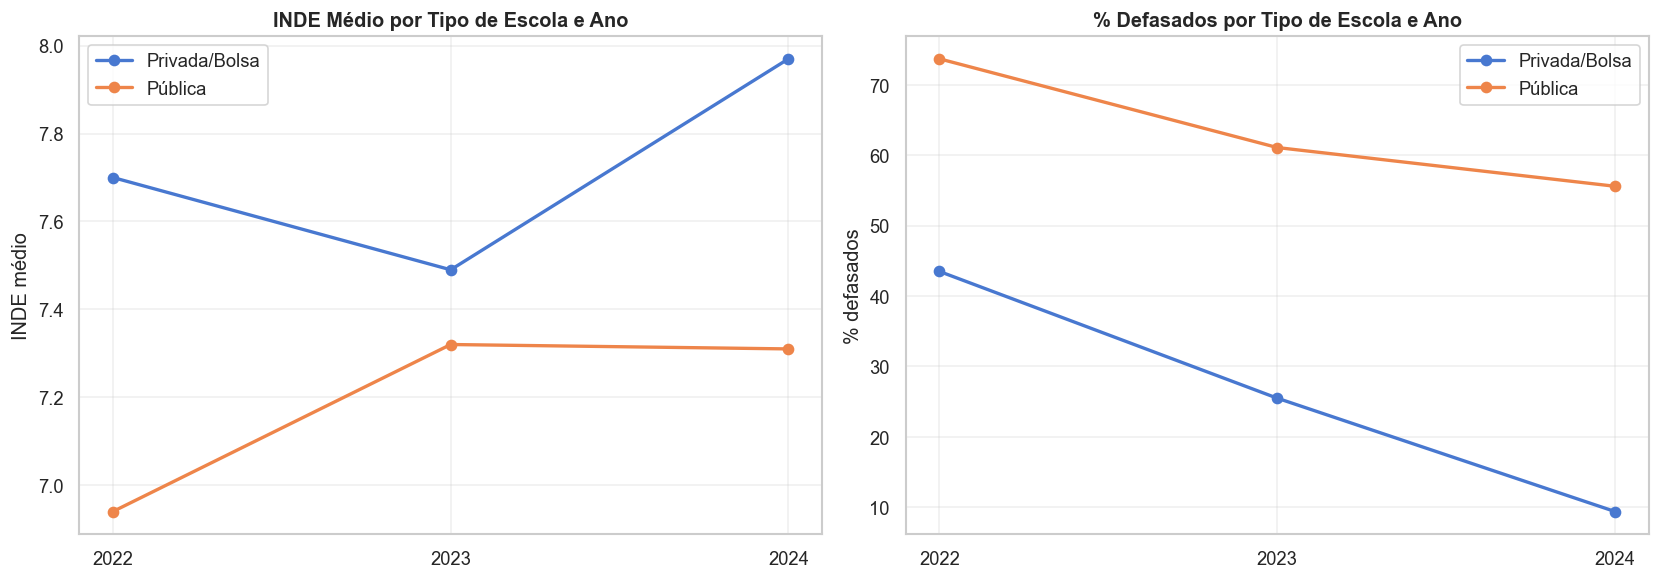

In [14]:
# Evolução dos alunos por tipo de instituição
df_inst = df[df['instituicao'].notna()].copy()

def classificar_escola(x):
    x_upper = str(x).upper()
    if 'PÚBLICA' in x_upper or 'PUBLICA' in x_upper:
        return 'Pública'
    elif 'PRIVADA' in x_upper or 'BOLSISTA' in x_upper or 'DECISÃO' in x_upper or 'JP II' in x_upper:
        return 'Privada/Bolsa'
    else:
        return np.nan  # 'Concluiu o 3º EM', 'Nenhuma das opções acima'

# Simplificar categorias de instituição
df_inst['tipo_escola'] = df_inst['instituicao'].apply(classificar_escola)

# Filtrar apenas pública e privada (remover "Outro" se houver poucos)
print('=== Distribuição por tipo de escola ===')
print(df_inst['tipo_escola'].value_counts().to_string())

# IDA e INDE médio por tipo de escola e ano
print('\n=== IDA médio por tipo de escola e ano ===')
pivot_ida = df_inst.pivot_table(index='tipo_escola', columns='ano', values='IDA', aggfunc='mean').round(2)
print(pivot_ida.to_string())

print('\n=== INDE médio por tipo de escola e ano ===')
pivot_inde = df_inst.pivot_table(index='tipo_escola', columns='ano', values='INDE', aggfunc='mean').round(2)
print(pivot_inde.to_string())

# % defasagem por tipo de escola e ano
print('\n=== % defasados por tipo de escola e ano ===')
pivot_def = df_inst.pivot_table(index='tipo_escola', columns='ano', values='IAN', 
                                 aggfunc=lambda x: (x < 10).mean() * 100).round(1)
print(pivot_def.to_string())

# Evolução longitudinal: mesmos alunos de escola pública 2022 -> 2024
pub_22 = df_inst[(df_inst['tipo_escola'] == 'Pública') & (df_inst['ano'] == 2022)]['RA']
pub_evol = df_inst[df_inst['RA'].isin(pub_22) & df_inst['ano'].isin([2022, 2024])]
pub_evol = pub_evol.groupby('RA').filter(lambda x: x['ano'].nunique() == 2)

if len(pub_evol) > 0:
    pivot_pub = pub_evol.pivot_table(index='RA', columns='ano', values='IAN', aggfunc='first').dropna()
    pivot_pub['defasado_2022'] = pivot_pub[2022] < 10
    pivot_pub['defasado_2024'] = pivot_pub[2024] < 10
    
    print(f'\n=== Alunos de escola pública: evolução da defasagem 2022 -> 2024 ===')
    print(f'  Total rastreados: {len(pivot_pub)}')
    
    recuperou = ((pivot_pub['defasado_2022']) & (~pivot_pub['defasado_2024'])).sum()
    manteve_def = ((pivot_pub['defasado_2022']) & (pivot_pub['defasado_2024'])).sum()
    piorou = ((~pivot_pub['defasado_2022']) & (pivot_pub['defasado_2024'])).sum()
    manteve_ok = ((~pivot_pub['defasado_2022']) & (~pivot_pub['defasado_2024'])).sum()
    
    print(f'  Recuperou (defasado -> adequado): {recuperou} ({recuperou/len(pivot_pub)*100:.1f}%)')
    print(f'  Manteve defasado: {manteve_def} ({manteve_def/len(pivot_pub)*100:.1f}%)')
    print(f'  Piorou (adequado -> defasado): {piorou} ({piorou/len(pivot_pub)*100:.1f}%)')
    print(f'  Manteve adequado: {manteve_ok} ({manteve_ok/len(pivot_pub)*100:.1f}%)')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# INDE por tipo de escola e ano
for tipo in pivot_inde.index:
    axes[0].plot(pivot_inde.columns.astype(str), pivot_inde.loc[tipo], marker='o', linewidth=2, label=tipo)
axes[0].set_title('INDE Médio por Tipo de Escola e Ano', fontweight='bold')
axes[0].set_ylabel('INDE médio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# % defasagem por tipo de escola e ano
for tipo in pivot_def.index:
    axes[1].plot(pivot_def.columns.astype(str), pivot_def.loc[tipo], marker='o', linewidth=2, label=tipo)
axes[1].set_title('% Defasados por Tipo de Escola e Ano', fontweight='bold')
axes[1].set_ylabel('% defasados')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 💡 Insights — Escola pública fecha a lacuna?

**Parcialmente. Ambos melhoram, mas a escola privada melhora mais rápido:**
- Defasagem na Privada/Bolsa: 43.5% -> 9.4% (-34pp) — quase zerou
- Defasagem na Pública: 73.7% -> 55.6% (-18pp) — caiu mas ainda mais da metade defasada
- O gap de INDE entre as duas fechou em 2023 (0.17) mas reabriu em 2024 (0.66)

**O programa funciona para escola pública — mas o ritmo é mais lento:**
- Dos 387 alunos de escola pública rastreados (2022->2024):
  - **40.3% recuperaram** a defasagem
  - 19.9% mantiveram-se adequados
  - 33.1% permanecem defasados
  - Apenas 6.7% pioraram

**💡 Para a ONG:** o programa reduz defasagem em alunos de escola pública (40% recuperam em 2 anos), mas os 33% que permanecem defasados podem precisar de intervenção mais intensiva. A diferença de ritmo entre pública e privada sugere que o suporte externo (bolsa, escola de melhor qualidade) acelera significativamente a recuperação

=== Taxa de abandono por tipo de escola ===
               taxa_abandono     n
tipo_escola                       
Privada/Bolsa           11.8   220
Pública                 30.1  1543

=== Taxa de abandono por tipo de escola e pedra ===
tipo_escola  Privada/Bolsa  Pública
pedra                              
Ametista              10.9     22.9
Quartzo               45.5     53.5
Topázio                2.7     18.9
Ágata                 23.5     36.7

=== Taxa de abandono por tipo de escola e status ===
                      mean                 count        
tipo_escola  Privada/Bolsa Pública Privada/Bolsa Pública
status                                                  
Primeiro ano          20.0    32.4             5     744
Veterano              11.6    27.9           215     799


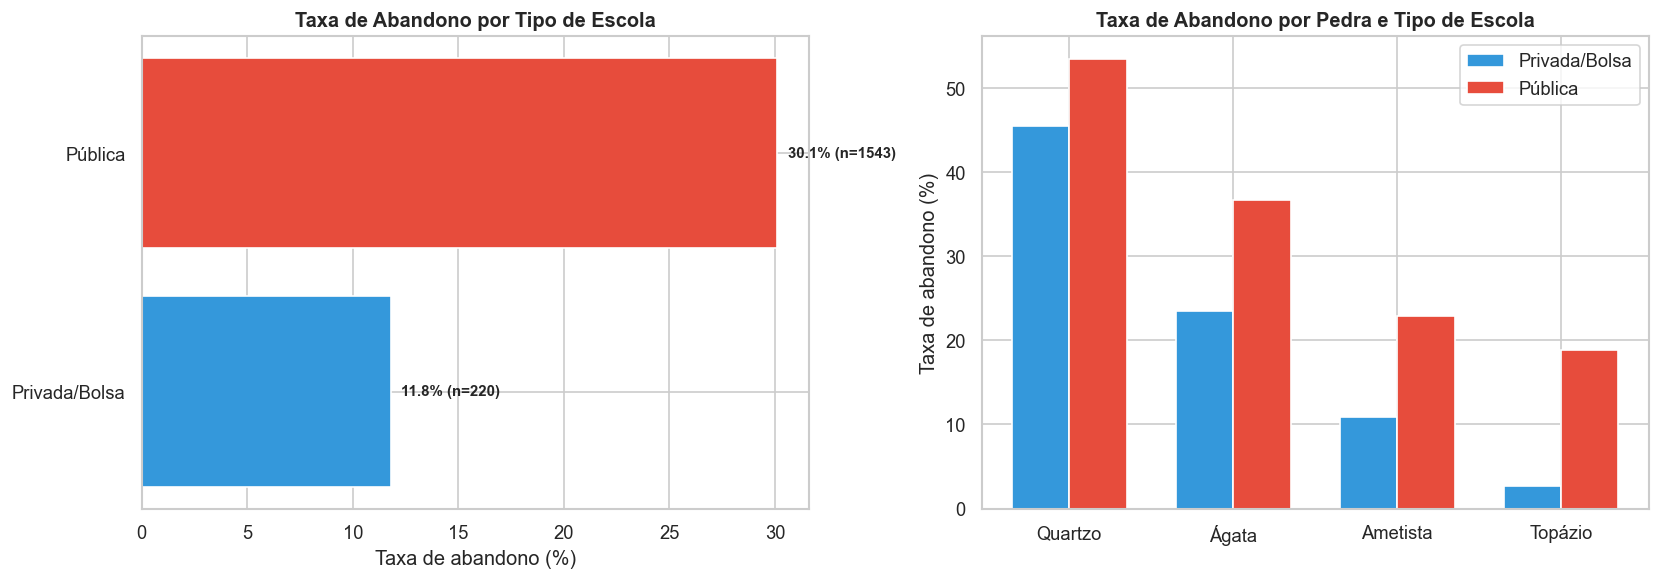

In [15]:
# Taxa de abandono por tipo de escola
df_abandono_escola = df_abandono[df_abandono['instituicao'].notna()].copy()

df_abandono_escola['tipo_escola'] = df_abandono_escola['instituicao'].apply(classificar_escola)
df_abandono_escola = df_abandono_escola[df_abandono_escola['tipo_escola'].notna()]

print('=== Taxa de abandono por tipo de escola ===')
taxa_escola = df_abandono_escola.groupby('tipo_escola')['saiu'].agg(['mean', 'count'])
taxa_escola.columns = ['taxa_abandono', 'n']
taxa_escola['taxa_abandono'] = (taxa_escola['taxa_abandono'] * 100).round(1)
print(taxa_escola.to_string())

# Cruzar: tipo de escola × pedra
print('\n=== Taxa de abandono por tipo de escola e pedra ===')
taxa_escola_pedra = df_abandono_escola.pivot_table(
    index='pedra', columns='tipo_escola', values='saiu', aggfunc='mean'
) * 100
print(taxa_escola_pedra.round(1).to_string())

# Cruzar: tipo de escola × primeiro ano
print('\n=== Taxa de abandono por tipo de escola e status ===')
df_abandono_escola['status'] = np.where(
    df_abandono_escola['ano_ingresso'] == df_abandono_escola['ano'], 'Primeiro ano', 'Veterano'
)
taxa_escola_status = df_abandono_escola.pivot_table(
    index='status', columns='tipo_escola', values='saiu', aggfunc=['mean', 'count']
)
taxa_escola_status['mean'] = (taxa_escola_status['mean'] * 100).round(1)
print(taxa_escola_status.to_string())

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa geral por tipo de escola
cores_escola = {'Pública': '#e74c3c', 'Privada/Bolsa': '#3498db'}
taxa_escola_sorted = taxa_escola.sort_values('taxa_abandono', ascending=True)
axes[0].barh(range(len(taxa_escola_sorted)), taxa_escola_sorted['taxa_abandono'],
             color=[cores_escola.get(e, '#999') for e in taxa_escola_sorted.index])
axes[0].set_yticks(range(len(taxa_escola_sorted)))
axes[0].set_yticklabels(taxa_escola_sorted.index)
axes[0].set_xlabel('Taxa de abandono (%)')
axes[0].set_title('Taxa de Abandono por Tipo de Escola', fontweight='bold')

for i, (escola, row) in enumerate(taxa_escola_sorted.iterrows()):
    axes[0].text(row['taxa_abandono'] + 0.5, i,
                 f'{row["taxa_abandono"]:.1f}% (n={int(row["n"])})',
                 va='center', fontsize=9, fontweight='bold')

# Taxa por escola × pedra
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
taxa_plot = taxa_escola_pedra.reindex(ordem_pedras).dropna(how='all')

x = np.arange(len(taxa_plot))
width = 0.35
for i, escola in enumerate(taxa_plot.columns):
    axes[1].bar(x + i * width - width/2, taxa_plot[escola], width,
                label=escola, color=cores_escola.get(escola, '#999'))

axes[1].set_xticks(x)
axes[1].set_xticklabels(taxa_plot.index)
axes[1].set_ylabel('Taxa de abandono (%)')
axes[1].set_title('Taxa de Abandono por Pedra e Tipo de Escola', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

##### 💡 Insights — Abandono × tipo de escola

**Escola pública abandona 2.5x mais:** 30.1% vs 11.8% da Privada/Bolsa

**O efeito persiste em todas as pedras — inclusive no Topázio:**
- Quartzo: Pública 53.5% vs Privada 45.5%
- Topázio: Pública **18.9%** vs Privada **2.7%**
- Mesmo alunos de escola pública com alto desempenho (Topázio) saem 7x mais que os de escola privada na mesma faixa

**Isso sugere que o abandono na escola pública não é apenas acadêmico:**
- Se fosse só desempenho, a taxa deveria convergir nas pedras altas — mas não converge
- Fatores socioeconômicos externos (necessidade de trabalhar, dificuldade de acesso, mudança de endereço) provavelmente contribuem

**💡 Para a ONG:**
- reduzir abandono na escola pública pode exigir ações além do acadêmico:
  - suporte logístico, bolsas de permanência, acompanhamento social. 
- O fato de alunos Topázio de escola pública saírem (18.9%) é um desperdício de potencial que merece investigação

**🤖 Para o modelo de ML (predição de abandono):** 
- `tipo_escola` deve ser feature — é o segundo fator mais forte após a pedra, e independente do desempenho acadêmico (efeito persiste em todas as pedras)

### ⭐️ Insight Final

**1. Mapa de risco multidimensional**

- Um score composto de 5 fatores (defasagem, IDA baixo, superestimação, IEG baixo, primeiro ano) cria um gradiente claro e consistente nos 3 anos: cada ponto de risco reduz o INDE em ~0.5 pontos.

- O programa está reduzindo o risco ao longo do tempo: alunos sem risco triplicaram (7% → 24%) e alunos de risco alto caíram (17% → 11%). Porém, 126 alunos (10.9% em 2024) ainda estão em risco alto — grupo prioritário para intervenção.

- Achado revelador: o IAA permanece acima de 8.0 mesmo com score 5 — os alunos mais vulneráveis não percebem sua situação.

---

**2. O efeito nível 3**

- O nível 3 (~12-14 anos, equivalente ao 7º/8º ano) é um gargalo acadêmico único: pior IDA da base (5.39 vs 6.58), maior superestimação (gap mediano 2.70) e alta taxa de abandono (36.1%).
- Por mais estranho que seja, não é o mais defasado (40.7%)
  - o problema não é estar na fase errada, é estar na fase certa mas não absorver o conteúdo.

- A combinação de desempenho baixo + autopercepção inflada é a mais perigosa:
  - o aluno não busca ajuda porque acha que não precisa.
  - Ao mesmo tempo, é onde o programa tem mais impacto (INDE +0.34 na coorte 2022→2024) — investir aqui tem alto retorno.

---

**3. Evasão e retenção**

- A evasão é real e significativa: 25-30% dos alunos saem a cada ano, e 96-97% deles não são concluintes (níveis ALFA a 6). 
- O perfil de quem sai é claro: IEG baixo (-0.331 com abandono), IDA baixo, pedra Quartzo (53.3% abandonam) e nível 3 (36.1%).
- O IEG é o indicador que mais prediz abandono — mais que o IDA. Um aluno com engajamento caindo é um sinal de alerta mais urgente que um aluno com notas caindo.
- O abandono na escola pública persiste em todas as pedras, inclusive no Topázio (18.9% vs 2.7%) — sugerindo que fatores socioeconômicos externos contribuem além das dificuldades acadêmicas

---

**4. Efeito da instituição de ensino**

- O programa funciona para escola pública: 40.3% dos alunos recuperaram a defasagem em 2 anos e apenas 6.7% pioraram.
- Mas o ritmo é mais lento que na Privada/Bolsa, que reduziu defasagem de 43.5% para 9.4% no mesmo período.
- A Pública saiu de 73.7% para 55.6% — melhora real, porém ainda mais da metade defasada.

- A diferença de ritmo sugere que o suporte externo (bolsa, escola de melhor qualidade) acelera significativamente a recuperação.
- Os 33% de alunos de escola pública que permanecem defasados após 2 anos podem precisar de intervenção mais intensiva.

---

**Idéias para a ONG:**
- O **score de risco composto** pode ser uma ferramenta prática de triagem anual para identificar os 10-15% mais vulneráveis
- O **nível 3** merece intervenção dupla: reforço acadêmico + feedback realista sobre desempenho
- Monitorar o **IEG** é mais eficaz para prevenir abandono do que monitorar notas
- Reduzir abandono na **escola pública** pode exigir ações além do acadêmico: suporte logístico, bolsas de permanência, acompanhamento social
- O fato de alunos **Topázio de escola pública** saírem (18.9%) é um desperdício de potencial que merece investigação individualizada

**🤖 Para o modelo de ML:**
- `tipo_escola` como feature — segundo fator mais forte de abandono, independente do desempenho
- Considerar criar **dois modelos**: um para risco de defasagem e outro para risco de abandono — os preditores são diferentes (defasagem depende mais de IDA e IAN; abandono depende mais de IEG e pedra)
- O score de risco composto pode servir como baseline para comparar com o modelo de ML
- Features prioritárias para abandono: IEG, IDA, IPV, pedra, nível, primeiro_ano, tipo_escola